In [1]:
import requests
import pandas as pd
import time

# All sectors and special areas
sectors = [
    "sector 1", "sector 2", "sector 3", "sector 4", "sector 5", "sector 6", "sector 7", "sector 8", "sector 9",
    "sector 10", "sector 10a", "sector 11", "sector 12", "sector 13", "sector 14", "sector 15", "sector 16",
    "sector 17", "sector 17a", "sector 17b", "sector 18", "sector 19", "sector 20", "sector 21", "sector 22",
    "sector 23", "sector 24", "sector 25", "sector 26", "sector 27", "sector 28", "sector 29", "sector 30",
    "sector 31", "sector 32", "sector 33", "sector 34", "sector 35", "sector 36", "sector 37", "sector 37a",
    "sector 37c", "sector 37d", "sector 38", "sector 39", "sector 40", "sector 41", "sector 42", "sector 43",
    "sector 44", "sector 45", "sector 46", "sector 47", "sector 48", "sector 49", "sector 50", "sector 51",
    "sector 52", "sector 53", "sector 54", "sector 55", "sector 56", "sector 57", "sector 58", "sector 59",
    "sector 60", "sector 61", "sector 62", "sector 63", "sector 63a", "sector 64", "sector 65", "sector 66",
    "sector 67", "sector 67a", "sector 68", "sector 69", "sector 70", "sector 71", "sector 72", "sector 73",
    "sector 74", "sector 75", "sector 76", "sector 77", "sector 78", "sector 79", "sector 80", "sector 81",
    "sector 82", "sector 82a", "sector 83", "sector 84", "sector 85", "sector 86", "sector 87", "sector 88",
    "sector 88a", "sector 88b", "sector 89", "sector 90", "sector 91", "sector 92", "sector 93", "sector 94",
    "sector 95", "sector 96", "sector 97", "sector 98", "sector 99", "sector 99a", "sector 100", "sector 101",
    "sector 102", "sector 103", "sector 104", "sector 105", "sector 106", "sector 107", "sector 108", "sector 109",
    "sector 110", "sector 111", "sector 112", "sector 113", "sector 114", "sector 115", 
    "gwal pahari", "manesar", "sohna road", "dwarka expressway"
]

# Add location context for better search results
sectors = [f"{s}, Gurugram, Haryana, India" for s in sectors]

results = []

for sector in sectors:
    url = f"https://nominatim.openstreetmap.org/search?format=json&polygon_geojson=1&q={sector}"
    response = requests.get(url, headers={"User-Agent": "geo-tester"})
    
    if response.status_code == 200:
        data = response.json()
        if data:
            bounding_box = data[0]['boundingbox']  # [south_lat, north_lat, west_lon, east_lon]
            geojson = data[0]['geojson']           # full polygon
            
            results.append({
                "sector": sector,
                "south_lat": bounding_box[0],
                "north_lat": bounding_box[1],
                "west_lon": bounding_box[2],
                "east_lon": bounding_box[3],
                "geojson": geojson
            })
            print(f"Fetched: {sector}")
        else:
            print(f"Not found: {sector}")
    else:
        print(f"Error fetching {sector}: {response.status_code}")
    
    time.sleep(1)  # Respect API rate limits

Fetched: sector 1, Gurugram, Haryana, India
Fetched: sector 2, Gurugram, Haryana, India
Fetched: sector 3, Gurugram, Haryana, India
Fetched: sector 4, Gurugram, Haryana, India
Fetched: sector 5, Gurugram, Haryana, India
Fetched: sector 6, Gurugram, Haryana, India
Fetched: sector 7, Gurugram, Haryana, India
Fetched: sector 8, Gurugram, Haryana, India
Fetched: sector 9, Gurugram, Haryana, India
Fetched: sector 10, Gurugram, Haryana, India
Fetched: sector 10a, Gurugram, Haryana, India
Fetched: sector 11, Gurugram, Haryana, India
Fetched: sector 12, Gurugram, Haryana, India
Fetched: sector 13, Gurugram, Haryana, India
Fetched: sector 14, Gurugram, Haryana, India
Fetched: sector 15, Gurugram, Haryana, India
Fetched: sector 16, Gurugram, Haryana, India
Fetched: sector 17, Gurugram, Haryana, India
Fetched: sector 17a, Gurugram, Haryana, India
Fetched: sector 17b, Gurugram, Haryana, India
Fetched: sector 18, Gurugram, Haryana, India
Fetched: sector 19, Gurugram, Haryana, India
Fetched: sector 

In [2]:
results

[{'sector': 'sector 1, Gurugram, Haryana, India',
  'south_lat': '28.3485815',
  'north_lat': '28.3716597',
  'west_lon': '76.9400968',
  'east_lon': '76.9592194',
  'geojson': {'type': 'Polygon',
   'coordinates': [[[76.9400968, 28.3601533],
     [76.9430168, 28.3602832],
     [76.9430178, 28.3563496],
     [76.9450411, 28.3564303],
     [76.9453702, 28.3516736],
     [76.9467722, 28.3517439],
     [76.9468639, 28.3485815],
     [76.9479303, 28.3491827],
     [76.948692, 28.3496209],
     [76.9508777, 28.3506047],
     [76.9509185, 28.3502756],
     [76.9521781, 28.3503463],
     [76.9521288, 28.3513216],
     [76.9533083, 28.3519209],
     [76.9567771, 28.3543183],
     [76.9567757, 28.3548492],
     [76.9592194, 28.3550367],
     [76.9585831, 28.3554094],
     [76.9582284, 28.3556912],
     [76.9576347, 28.3562547],
     [76.9573267, 28.356607],
     [76.9573246, 28.3565013],
     [76.9561191, 28.3564473],
     [76.9561195, 28.3569945],
     [76.9571494, 28.3570005],
     [76.955268

In [3]:
# Save results to CSV
df = pd.DataFrame(results)
df.to_csv("gurgaon_sectors_geo.csv", index=False)

print("✅ Saved to gurgaon_sectors_geo.csv")

✅ Saved to gurgaon_sectors_geo.csv


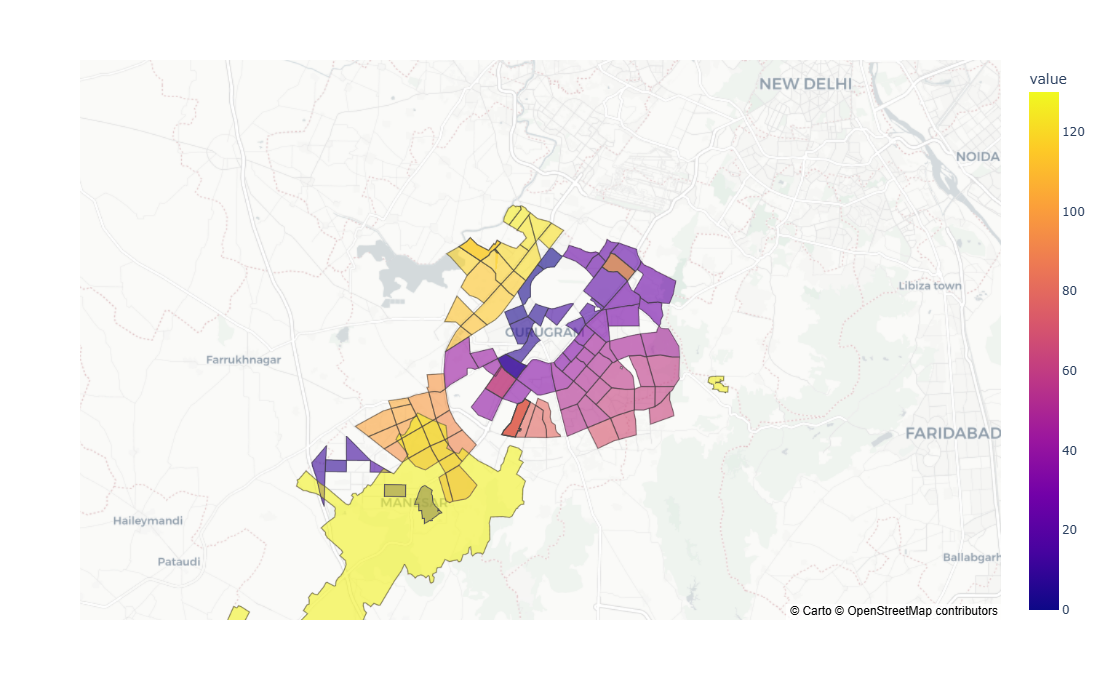

In [7]:
import pandas as pd
import json
import ast

# Load the CSV
df = pd.read_csv("gurgaon_sectors_geo.csv")

# Convert geojson column to Python dicts
def ensure_dict(val):
    if isinstance(val, dict):
        return val
    if isinstance(val, str):
        try:
            return json.loads(val)  # Try strict JSON
        except json.JSONDecodeError:
            return ast.literal_eval(val)  # Fallback for Python-like dicts
    return None

df['geojson'] = df['geojson'].apply(ensure_dict)

# Build FeatureCollection
features = []
for _, row in df.iterrows():
    features.append({
        "type": "Feature",
        "geometry": row['geojson'],
        "properties": {"sector": row['sector']}
    })

geojson_data = {
    "type": "FeatureCollection",
    "features": features
}

# Example value for coloring
df['value'] = range(len(df))

import plotly.express as px
fig = px.choropleth_mapbox(
    df,
    geojson=geojson_data,
    locations="sector",
    featureidkey="properties.sector",
    color="value",
    mapbox_style="carto-positron",
    center={"lat": 28.4595, "lon": 77.0266},
    zoom=10,
    opacity=0.6,
    height = 700
)
fig.show()
